# EDA - Bank Credit-Card Data

`creditcard.csv` features are PCA-anonymised (`V1..V28`) plus `Time` and `Amount`. This dataset is **extremely** imbalanced (~0.17% fraud).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


In [2]:
from src import config, data_loading, cleaning
raw = data_loading.load_creditcard()
print('raw shape:', raw.shape)
raw.head()

raw shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Missing values & duplicates

In [4]:
display(cleaning.missing_value_report(raw).head(10))
print('exact duplicate rows:', raw.duplicated().sum())
df = cleaning.clean_creditcard(raw)
print('after dedup:', df.shape)

,missing_count,missing_pct,dtype
Time,0,0.0,float64
V1,0,0.0,float64
V2,0,0.0,float64
V3,0,0.0,float64
V4,0,0.0,float64
V5,0,0.0,float64
V6,0,0.0,float64
V7,0,0.0,float64
V8,0,0.0,float64
V9,0,0.0,float64


exact duplicate rows: 1081


after dedup: (283726, 31)


## Class imbalance (severe)

,count,pct
Class,,
0,283253,99.8333
1,473,0.1667


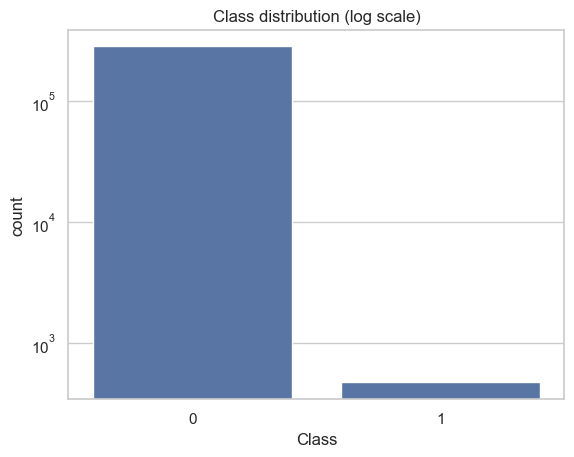

In [5]:
bal = cleaning.class_balance(df, config.CREDITCARD_TARGET)
display(bal)
ax = sns.countplot(x=config.CREDITCARD_TARGET, data=df)
ax.set_yscale('log'); ax.set_title('Class distribution (log scale)')
plt.savefig(config.FIGURES_DIR/'cc_class_balance.png', dpi=120, bbox_inches='tight'); plt.show()

## Transaction Amount by class

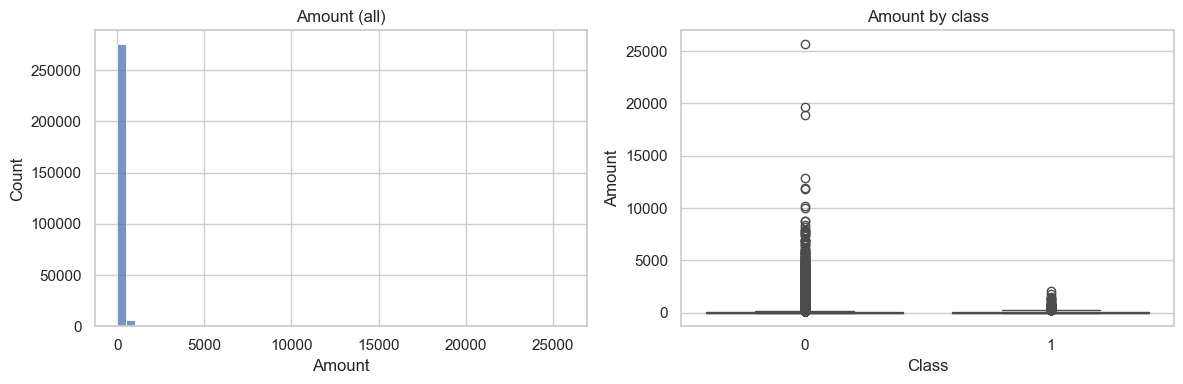

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Amount'], bins=50, ax=axes[0]).set_title('Amount (all)')
sns.boxplot(x=config.CREDITCARD_TARGET, y='Amount', data=df, ax=axes[1])
axes[1].set_title('Amount by class')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'cc_amount.png', dpi=120, bbox_inches='tight'); plt.show()

## Which PCA components separate fraud best?

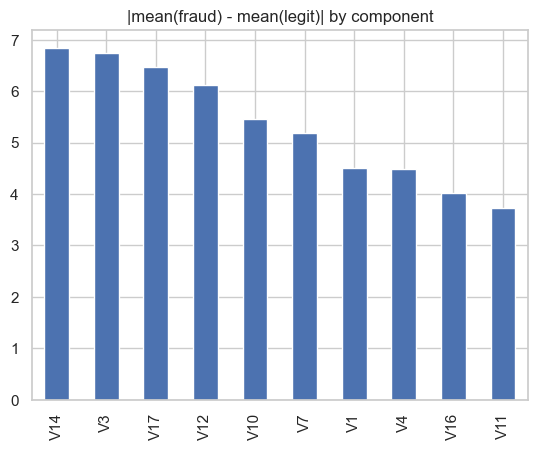

V14    6.847614
V3     6.742452
V17    6.474249
V12    6.112730
V10    5.460937
V7     5.186359
V1     4.511719
V4     4.483031
V16    4.008801
V11    3.722350
dtype: float64

In [7]:
vcols = [c for c in df.columns if c.startswith('V')]
sep = (df[df[config.CREDITCARD_TARGET]==1][vcols].mean() - df[df[config.CREDITCARD_TARGET]==0][vcols].mean()).abs().sort_values(ascending=False)
sep.head(10).plot.bar(title='|mean(fraud) - mean(legit)| by component'); plt.show()
sep.head(10)

### Takeaways
- ~0.17% positives: accuracy is useless; optimise **AUC-PR / recall at fixed precision**.
- A handful of PCA components carry most of the separating signal.
- `Amount` should be scaled; `V1..V28` are already standardised PCA outputs.